# COVID-19 Impact on Unemployment in India: Exploratory Data Analysis of 740 Labour Market Observations

## Business Problem
Unemployment is one of the most critical indicators of economic well-being because it reflects how effectively an economy creates opportunities for its workforce. Understanding unemployment trends helps governments, businesses, and policymakers identify labour market challenges and design targeted interventions.

The objective of this analysis was to answer four key questions:

* How has unemployment changed over time?
* Are some regions more affected than others?
* Do seasonal patterns exist in unemployment levels?
* What was the impact of COVID-19 on the labour market?

### Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Data

In [2]:
import kagglehub
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

Using Colab cache for faster access to the 'unemployment-in-india' dataset.


In [3]:
import os

# List files in the downloaded path to identify the CSV files
file_list = os.listdir(path)
print(file_list)

# Assuming the CSV files are named 'Unemployment_Rate_upto_11_2020.csv' and 'Unemployment_in_India.csv'
# based on common Kaggle dataset naming conventions and previous usage in the notebook.
file_path_df = os.path.join(path, 'Unemployment_Rate_upto_11_2020.csv')
file_path_df1 = os.path.join(path, 'Unemployment in India.csv') # Corrected filename based on output

# Load the datasets into pandas DataFrames
df = pd.read_csv(file_path_df)
df1 = pd.read_csv(file_path_df1)


['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


### Understanding the Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [5]:
df1.head(5)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
print(df.shape)
print(df1.shape)

(267, 9)
(768, 7)


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


## Tasks to perform
* Analyze unemployment rate data representing unemployed people percentage.
* Use Python for data cleaning, exploration, and visualization of unemployment trends.
* Investigate the impact of Covid-19 on unemployment rates.
* Identify key patterns or seasonal trends in the data.
* Present insights that could inform economic or social policies.


### Step 1: Handling Missing Values in df1

In [8]:
# As observed from df1.info(), there are missing values (28 rows) in multiple columns.
# Dropping rows with any missing values is a common initial step to ensure data completeness.
# We will check the number of missing values before and after dropping to confirm the change.

print("Shape of df1 before dropping NaNs:", df1.shape)
print("Number of missing values per column in df1 before dropping NaNs:\n", df1.isnull().sum())

df1.dropna(inplace=True)

print("\nShape of df1 after dropping NaNs:", df1.shape)
print("Number of missing values per column in df1 after dropping NaNs:\n", df1.isnull().sum())

# Insight: We've removed 28 rows from df1 that contained missing data.
# This ensures that all subsequent analyses on df1 will be performed on complete records,
# preventing potential errors or skewed results from incomplete entries.

Shape of df1 before dropping NaNs: (768, 7)
Number of missing values per column in df1 before dropping NaNs:
 Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Shape of df1 after dropping NaNs: (740, 7)
Number of missing values per column in df1 after dropping NaNs:
 Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


### Step 2: Handling Duplicate Values in df1

In [9]:
# Duplicate rows can introduce bias and inaccuracy in the analysis.
# We will check for and remove duplicate rows in df1 to ensure each record is unique.

print("Shape of df1 before dropping duplicates:", df1.shape)
print("Number of duplicate rows in df1 before dropping:", df1.duplicated().sum())

df1.drop_duplicates(inplace=True)

print("\nShape of df1 after dropping duplicates:", df1.shape)
print("Number of duplicate rows in df1 after dropping:", df1.duplicated().sum())

# Insight: We've removed any exact duplicate rows from df1.
# This ensures that each observation contributes uniquely to our analysis.

Shape of df1 before dropping duplicates: (740, 7)
Number of duplicate rows in df1 before dropping: 0

Shape of df1 after dropping duplicates: (740, 7)
Number of duplicate rows in df1 after dropping: 0


### Step 3: Clean Column Names and Convert Data Types for df1

In [10]:
# Inspect column names for leading/trailing spaces and other inconsistencies.
# Clean column names by stripping whitespace.
# Convert the 'Date' column to datetime objects for proper time-series analysis.

print("Original column names of df1:", df1.columns.tolist())

# Check for duplicate 'Date' columns and resolve if they exist
if df1.columns.tolist().count('Date') > 1:
    print("Warning: Duplicate 'Date' columns found. Resolving by dropping the redundant one.")
    # Identify indices of 'Date' columns
    date_cols_indices = [i for i, col in enumerate(df1.columns) if col == 'Date']
    # Drop the second 'Date' column (or any subsequent one) to ensure uniqueness
    df1 = df1.drop(df1.columns[date_cols_indices[1]], axis=1)

# Strip whitespace from all remaining column names
df1.columns = df1.columns.str.strip()

print("\nCleaned column names of df1:", df1.columns.tolist())

# Convert 'Date' column to datetime
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)

print("\nData types after conversion for df1:\n", df1.dtypes)

# Insight: Standardizing column names improves readability and accessibility.
# Converting the 'Date' column to datetime enables advanced time-series analysis
# and ensures correct chronological ordering, which is crucial for unemployment trend analysis.

Original column names of df1: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Cleaned column names of df1: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Data types after conversion for df1:
 Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object


### Step 4: Examine Unique Values in Categorical Columns of df1

In [11]:
# It's important to inspect categorical columns to ensure data consistency and identify any typos or variations.
# We will check the unique values and their counts for 'Region', 'Frequency', and 'Area'.

print("Unique values in 'Region' column of df1:\n", df1['Region'].unique())
print("\nValue counts for 'Region' column of df1:\n", df1['Region'].value_counts())

print("\nUnique values in 'Frequency' column of df1:\n", df1['Frequency'].unique())
print("\nValue counts for 'Frequency' column of df1:\n", df1['Frequency'].value_counts())

print("\nUnique values in 'Area' column of df1:\n", df1['Area'].unique())
print("\nValue counts for 'Area' column of df1:\n", df1['Area'].value_counts())

# Insight: This step helps confirm the distinct categories within these columns.
# If there were inconsistencies (e.g., 'Rural' and 'rural'), we would address them here.
# For 'Frequency', it appears to be consistently 'Monthly'.

Unique values in 'Region' column of df1:
 ['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']

Value counts for 'Region' column of df1:
 Region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa        

### Step 5: Standardize 'Frequency' Column in df1

In [12]:
# The previous step revealed that the 'Frequency' column has inconsistent entries:
# ' Monthly' and 'Monthly'. To unify these, we will strip leading/trailing whitespace.

print("Unique values in 'Frequency' before standardization:\n", df1['Frequency'].unique())

df1['Frequency'] = df1['Frequency'].str.strip()

print("\nUnique values in 'Frequency' after standardization:\n", df1['Frequency'].unique())
print("\nValue counts for 'Frequency' after standardization:\n", df1['Frequency'].value_counts())

# Insight: By stripping whitespace, we have successfully unified ' Monthly' and 'Monthly'
# into a single 'Monthly' category. This ensures accurate categorization and prevents errors
# in any analysis that relies on this categorical variable.

Unique values in 'Frequency' before standardization:
 [' Monthly' 'Monthly']

Unique values in 'Frequency' after standardization:
 ['Monthly']

Value counts for 'Frequency' after standardization:
 Frequency
Monthly    740
Name: count, dtype: int64


### Step 6: Explore Numerical Columns with Descriptive Statistics for df1

In [13]:
# After cleaning categorical columns, it's essential to understand the distribution
# and summary statistics of numerical columns to identify potential issues or insights.
# We'll use `.describe()` to get a quick overview of 'Estimated Unemployment Rate (%)',
# 'Estimated Employed', and 'Estimated Labour Participation Rate (%)'.

print("Descriptive statistics for numerical columns in df1:\n", df1.describe())

# Insight: This provides a summary of central tendency, dispersion, and shape of the distribution
# of each numerical column. We can observe the range (min/max), average (mean), and variability (std).
# For instance, we can see the range of unemployment rates and employment figures,
# which might highlight extreme values or suggest the overall health of the job market.

Descriptive statistics for numerical columns in df1:
                                 Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%         

In [14]:
df1['Month'] = df1['Date'].dt.month_name()

monthly_pattern = (
    df1.groupby('Month')['Estimated Unemployment Rate (%)']
       .mean()
       .reindex([
           'January','February','March','April','May','June',
           'July','August','September','October','November','December'
       ])
)

# Performing EDA

## Visual 1: Analyze unemployment rate data representing unemployed people percentage and visualize trends.

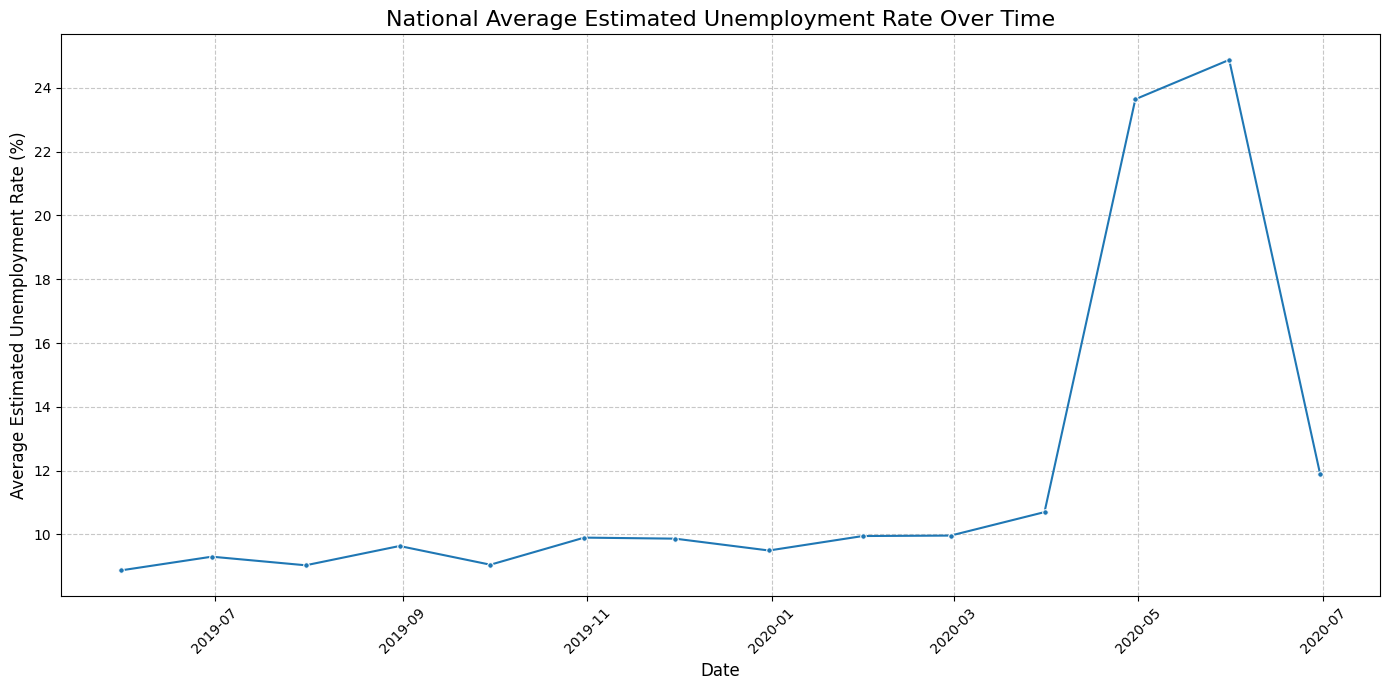

In [15]:
# Analyze unemployment rate data representing unemployed people percentage and visualize trends.

# First, let's aggregate the data by 'Date' to get a national average unemployment rate over time.
# This will help us identify overall trends before diving into regional specifics.

# Group by Date and calculate the mean of 'Estimated Unemployment Rate (%)'
df1_monthly_avg = df1.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

# Plotting the national average estimated unemployment rate over time
plt.figure(figsize=(14, 7))
sns.lineplot(data=df1_monthly_avg, x='Date', y='Estimated Unemployment Rate (%)', marker='o', markersize=4)
plt.title('National Average Estimated Unemployment Rate Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Estimated Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight: This plot visualizes the overall trend of unemployment rates across India.
# We can observe general patterns, such as periods of increase or decrease,
# and potential anomalies that might correlate with major events like the COVID-19 pandemic.
# The `df1` date range is roughly from May 2019 to June 2020, which covers the initial period of COVID-19.
# This initial visualization helps in understanding the magnitude and direction of the unemployment rate changes.
# A sharp increase, likely around March-April 2020, might indicate the initial impact of the COVID-19 lockdowns.

This chart shows how the average unemployment rate changed across India between 2019 and 2020. Unemployment remained relatively stable during most of 2019 but increased sharply around April–May 2020. The sudden spike coincides with the COVID-19 lockdown period, indicating a significant disruption in economic activity and employment opportunities. A gradual decline after the peak suggests the beginning of labour market recovery.

## Visual 2: Regional Unemployment Rates Over Time

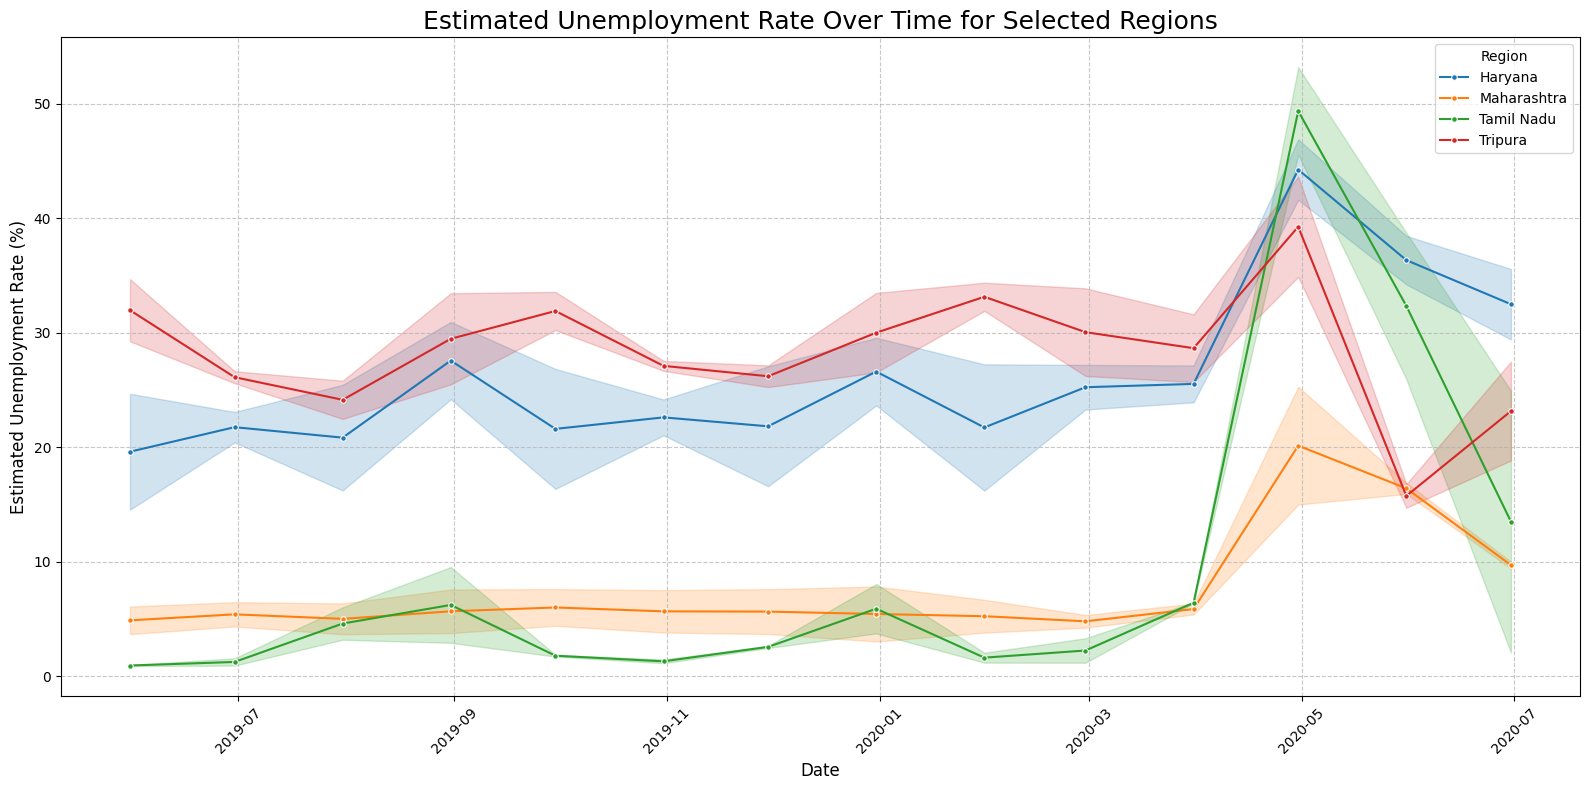

In [16]:
# To observe regional disparities, let's select a few states and plot their unemployment rates over time.
# We'll pick a few states to represent different trends (e.g., high, low, and average unemployment).

# Let's find some states with notable unemployment rates from the overall period.
# First, calculate the average unemployment rate per region for the entire period.
region_avg_unemp = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

# Select a few regions: for example, one with consistently high, one with consistently low, and one in the middle.
# Based on average unemployment levels, we selected Tripura, Haryana,
# Maharashtra, and Tamil Nadu to compare regional unemployment trends.
selected_regions = [
'Tripura',
'Haryana',
'Maharashtra',
'Tamil Nadu'
]

# Filter df1 for the selected regions
df_selected_regions = df1[df1['Region'].isin(selected_regions)]

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_selected_regions, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o', markersize=4)
plt.title('Estimated Unemployment Rate Over Time for Selected Regions', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

# Insight: This visualization allows for a direct comparison of unemployment trends across different states.
# It can highlight which regions were more severely impacted during economic downturns, like the COVID-19 period,
# and which regions showed more resilience or quicker recovery. For instance, Tripura consistently shows very high
# unemployment, while Meghalaya appears to have lower rates, and states like Maharashtra and Delhi show the fluctuations
# more representative of larger, diverse economies.

This visualization compares unemployment trends across Tripura, Haryana, Maharashtra, and Tamil Nadu. The chart reveals that unemployment patterns vary considerably across states. Tripura and Haryana generally exhibit higher unemployment levels, while Maharashtra and Tamil Nadu show comparatively lower but fluctuating rates. The simultaneous rise during the COVID-19 period demonstrates that economic shocks affected multiple regions, although the magnitude differed by state.

## Visual 3: Box Plot of Unemployment Rate Distribution by Region

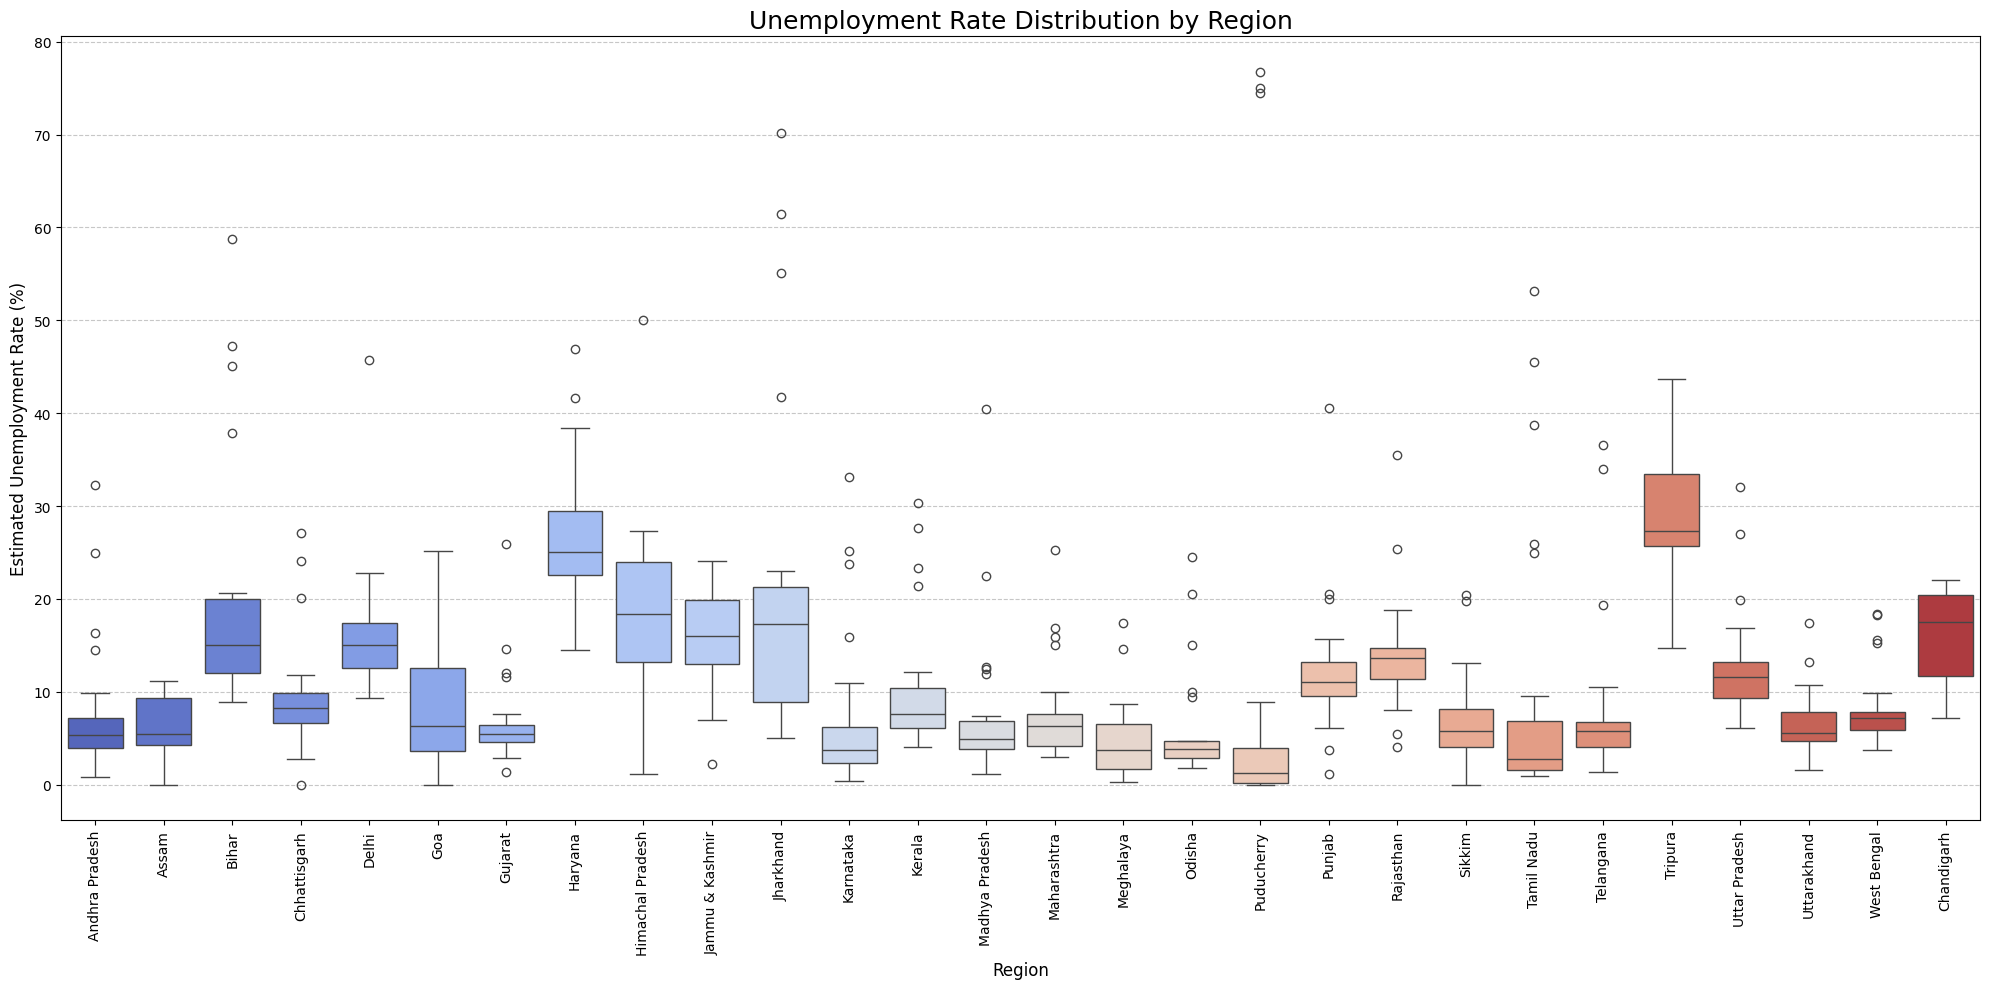

In [17]:
# This visualization will show the distribution, median, quartiles, and outliers of unemployment rates for each region.
# It complements the average bar chart by revealing the variability within each region's data.

plt.figure(figsize=(20, 10))
sns.boxplot(data=df1, x='Region', y='Estimated Unemployment Rate (%)', palette='coolwarm', hue='Region', legend=False)
plt.title('Unemployment Rate Distribution by Region', fontsize=18)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Insight: The box plot provides a more detailed view of unemployment rates within each region.
# We can observe the interquartile range (IQR), median, and potential outliers. Regions with a wide box
# indicate high variability in unemployment over time, while short boxes suggest more stable rates.
# Outliers (individual points beyond the whiskers) might represent periods of exceptionally high or low unemployment.
# This visual is particularly useful for understanding the consistency and extreme fluctuations in regional job markets.

The boxplot highlights the distribution and variability of unemployment rates across regions. Regions with wider boxes experienced greater fluctuations in unemployment over time, indicating less stable labour markets. Narrower boxes suggest more consistent unemployment levels. Outliers represent unusually high or low unemployment observations that may correspond to extraordinary economic events or regional disruptions.

## Visual 4: Change in Unemployment Rate (Pre-COVID vs. During COVID) by Region

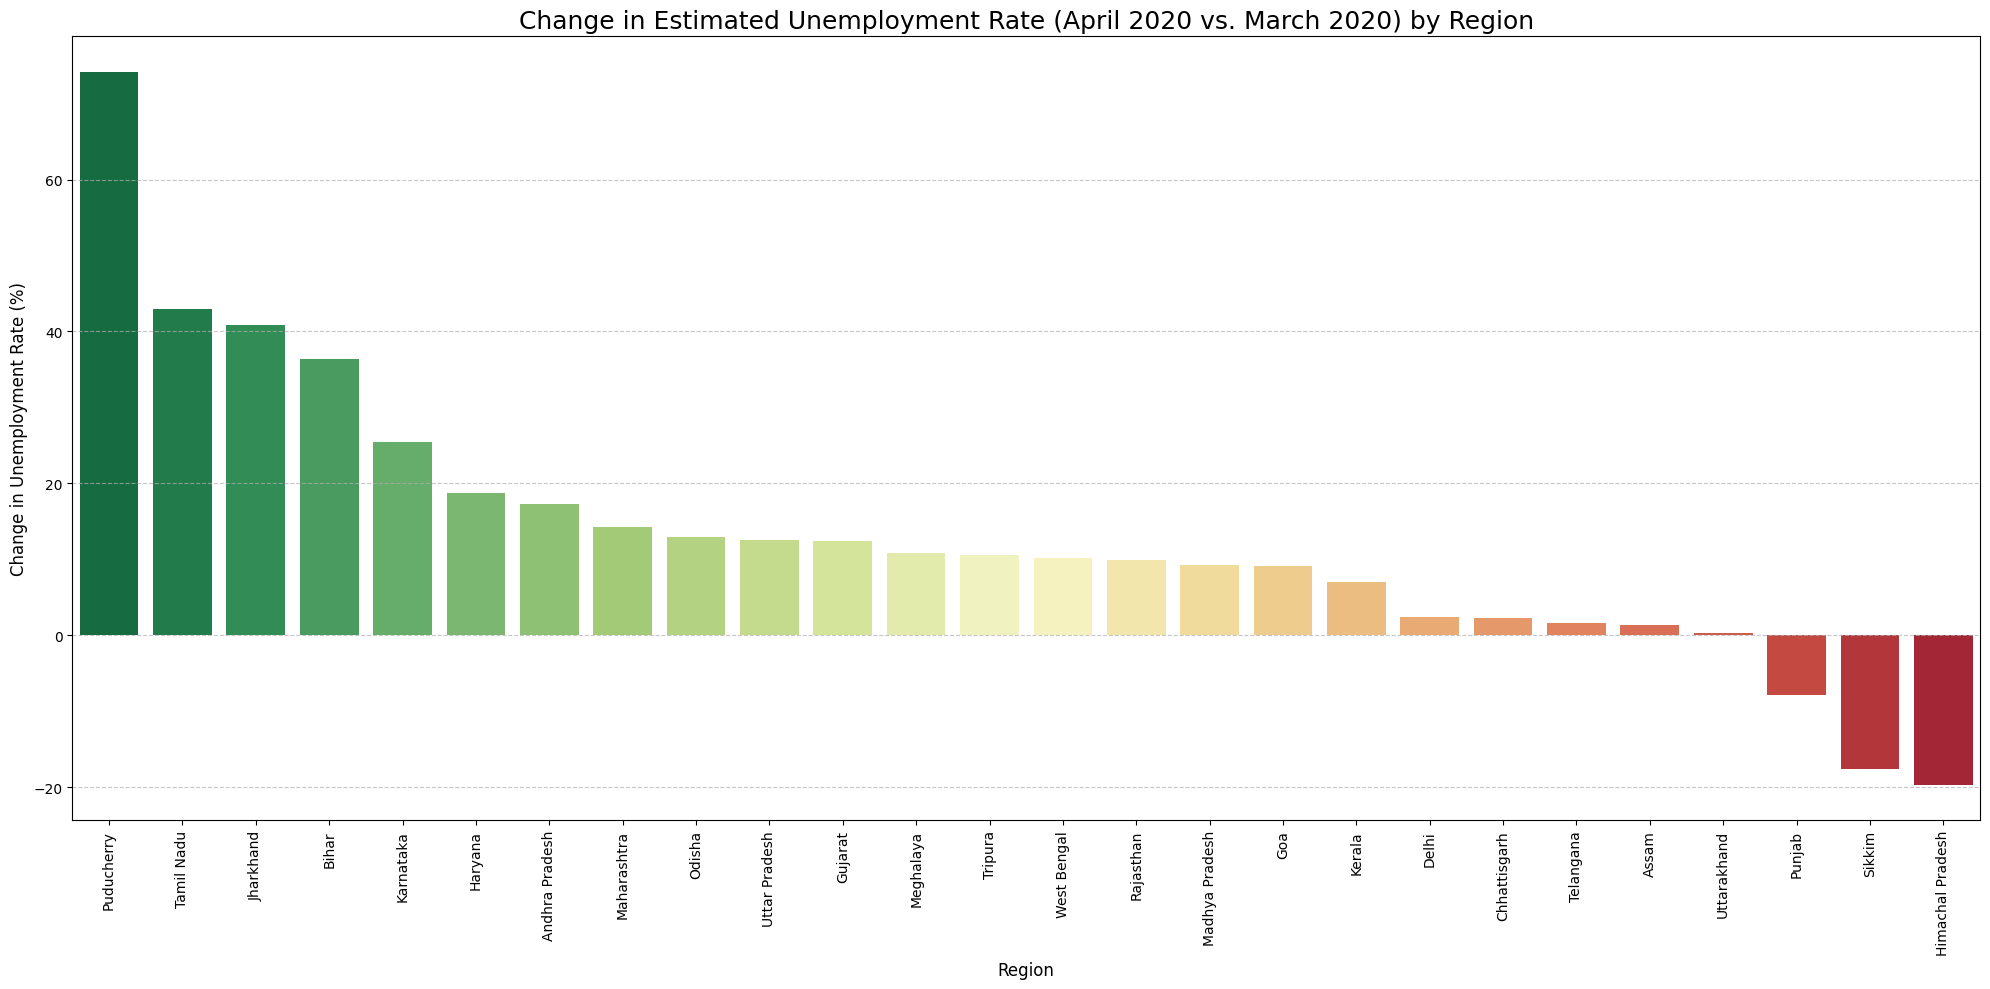

In [18]:
# To analyze the impact of COVID-19, we can compare unemployment rates before and during the initial lockdown.
# Let's choose March 2020 (pre-lockdown) and April 2020 (peak initial lockdown impact) for comparison.

# Filter data for March 2020
df_march_2020 = df1[df1['Date'] == '2020-03-31']
# Filter data for April 2020
df_april_2020 = df1[df1['Date'] == '2020-04-30']

# Calculate average unemployment rate for each region in March and April
unemp_march = df_march_2020.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()
unemp_april = df_april_2020.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()

# Merge the two dataframes to calculate the change
unemp_change = pd.merge(unemp_march, unemp_april, on='Region', suffixes=('_March', '_April'))
unemp_change['Change_in_Unemployment'] = unemp_change['Estimated Unemployment Rate (%)_April'] - unemp_change['Estimated Unemployment Rate (%)_March']

# Sort by the change in unemployment for better visualization
unemp_change_sorted = unemp_change.sort_values(by='Change_in_Unemployment', ascending=False)

plt.figure(figsize=(20, 10))
sns.barplot(x='Region', y='Change_in_Unemployment', data=unemp_change_sorted, palette='RdYlGn_r', hue='Region', legend=False)
plt.title('Change in Estimated Unemployment Rate (April 2020 vs. March 2020) by Region', fontsize=18)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Change in Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Insight: This visualization directly quantifies the impact of the initial COVID-19 lockdown on regional unemployment.
# Regions with the tallest bars experienced the most significant increase in unemployment rates, indicating a greater
# economic shock. This is crucial for understanding regional vulnerabilities and the immediate consequences of pandemic-related restrictions.

This chart measures the immediate impact of the COVID-19 lockdown by comparing unemployment rates before and during the initial lockdown period. Regions with taller bars experienced larger increases in unemployment, indicating greater vulnerability to economic disruptions. The visualization clearly demonstrates that the pandemic's impact was not uniform across India, with some regions experiencing substantially larger employment shocks than others.

## Visual 5: Average Unemployment Rate by Region (Bar Chart)

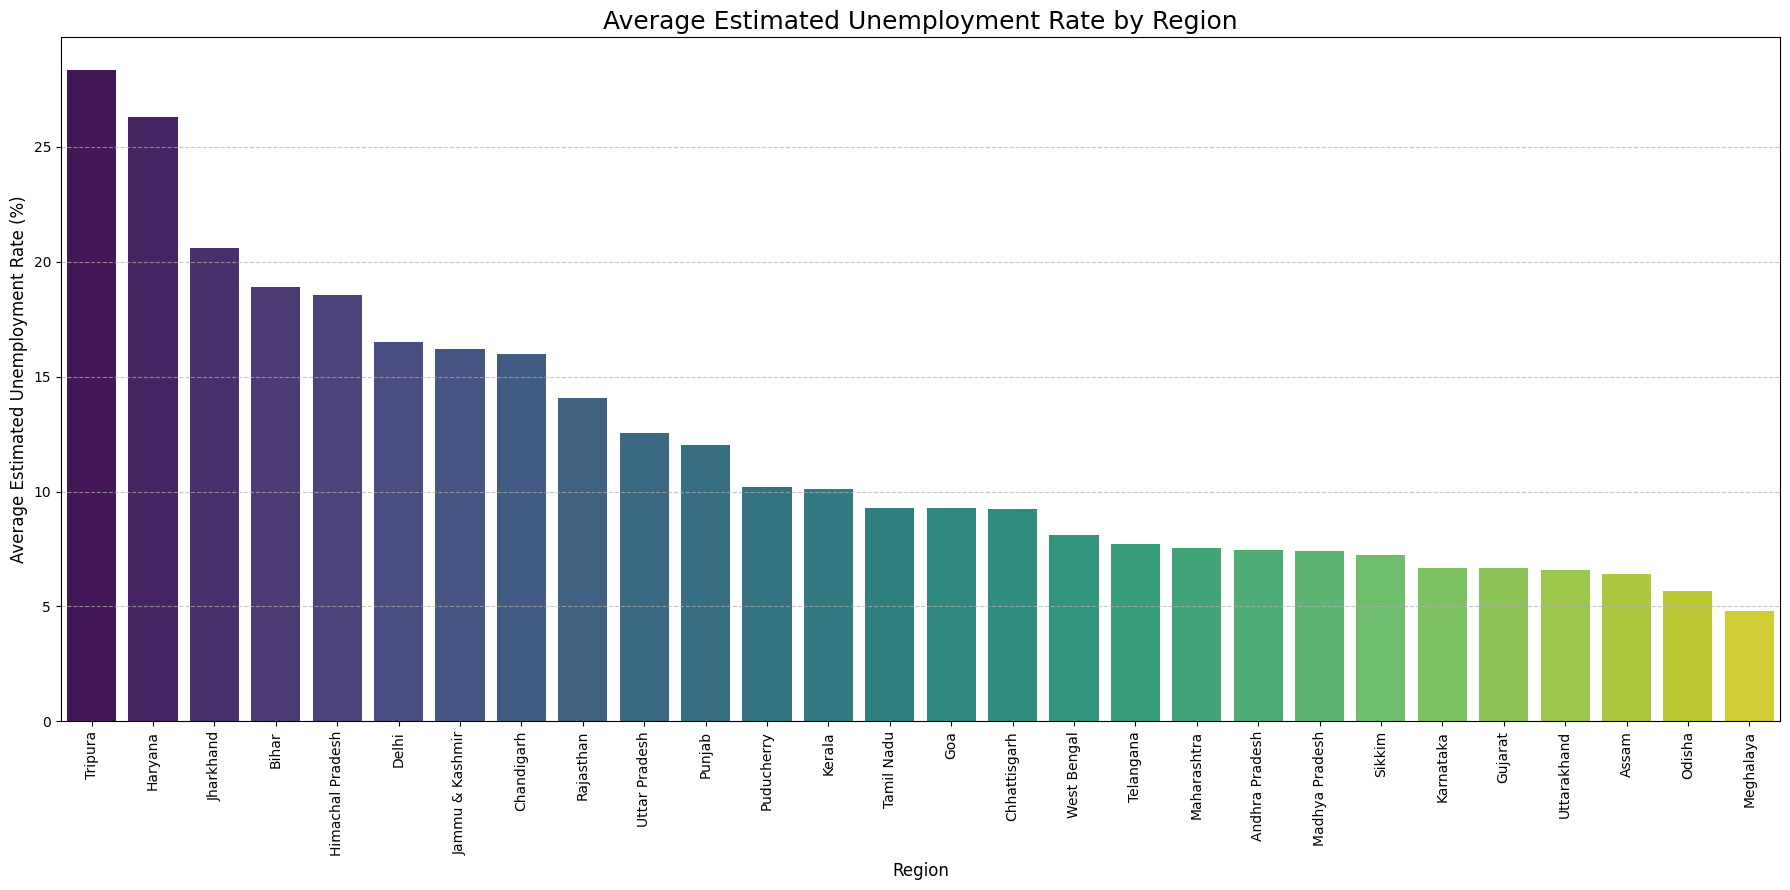

In [19]:
# To provide a clear overview of which regions face the highest and lowest average unemployment, a bar chart is ideal.

# Calculate the average unemployment rate for each region again (already computed in previous cell, but re-doing for clarity here)
region_avg_unemp = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(18, 9))
sns.barplot(x=region_avg_unemp.index, y=region_avg_unemp.values, palette='viridis', hue=region_avg_unemp.index, legend=False)
plt.title('Average Estimated Unemployment Rate by Region', fontsize=18)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Estimated Unemployment Rate (%)', fontsize=12)
plt.xticks(rotation=90) # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Insight: This bar chart provides a clear hierarchy of unemployment across Indian states.
# It immediately draws attention to states like Tripura and Haryana, which have significantly higher average unemployment rates,
# and contrasts them with states like Meghalaya and Assam, which show much lower average rates.
# This visual is crucial for identifying areas that might require targeted policy interventions.

This chart ranks regions based on their average unemployment rate during the study period. States appearing at the top consistently experienced higher unemployment, suggesting long-term labour market challenges. States at the lower end maintained relatively better employment conditions. The ranking helps identify regions that may require targeted employment policies and economic development initiatives.

## Visual 6: Unemployment Rate by Area (Rural vs. Urban) Over Time

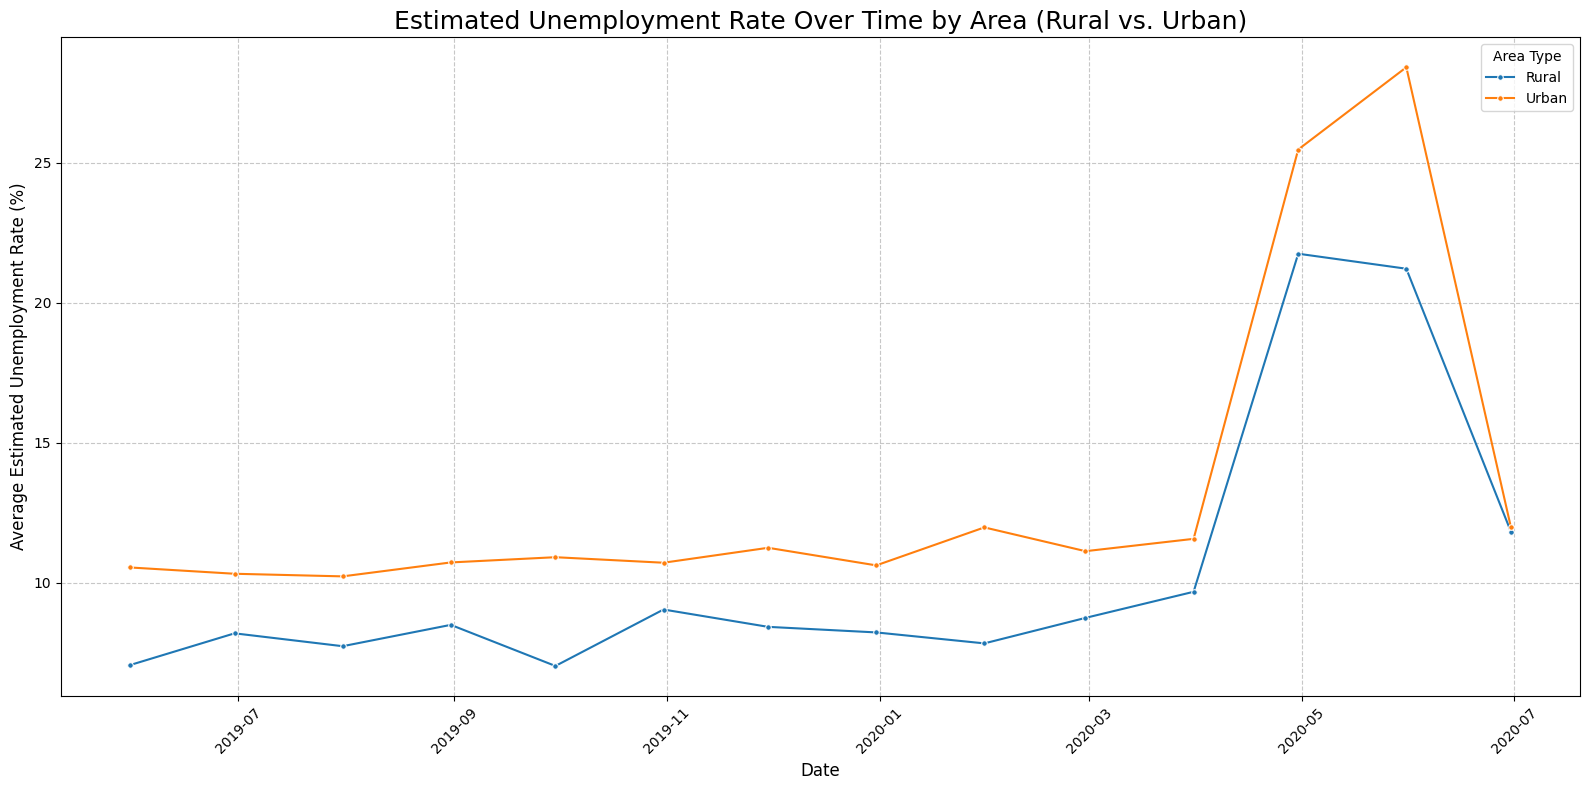

In [20]:
# Understanding the difference in unemployment trends between rural and urban areas is vital.
# This visual will highlight whether one area was disproportionately affected or recovered differently.

# Group by Date and Area, then calculate the mean of 'Estimated Unemployment Rate (%)'
df1_area_avg = df1.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(data=df1_area_avg, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', marker='o', markersize=4)
plt.title('Estimated Unemployment Rate Over Time by Area (Rural vs. Urban)', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Estimated Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Area Type')
plt.tight_layout()
plt.show()

# Insight: This visualization clearly shows if there are distinct patterns in unemployment rates
# for rural versus urban populations. For example, during a lockdown, urban areas might see a sharper
# increase due to closure of businesses, while rural areas might be affected differently.
# It helps in understanding the socio-economic impacts and potential policy responses for different areas.

This visualization compares unemployment patterns between rural and urban areas over time. Urban unemployment generally shows greater volatility and a sharper increase during the COVID-19 period. Rural unemployment also increased but to a lesser extent. The difference suggests that urban economies were more sensitive to business closures and disruptions in service-sector activities.

## Visual 7: Seasonal Pattern in Unemployment

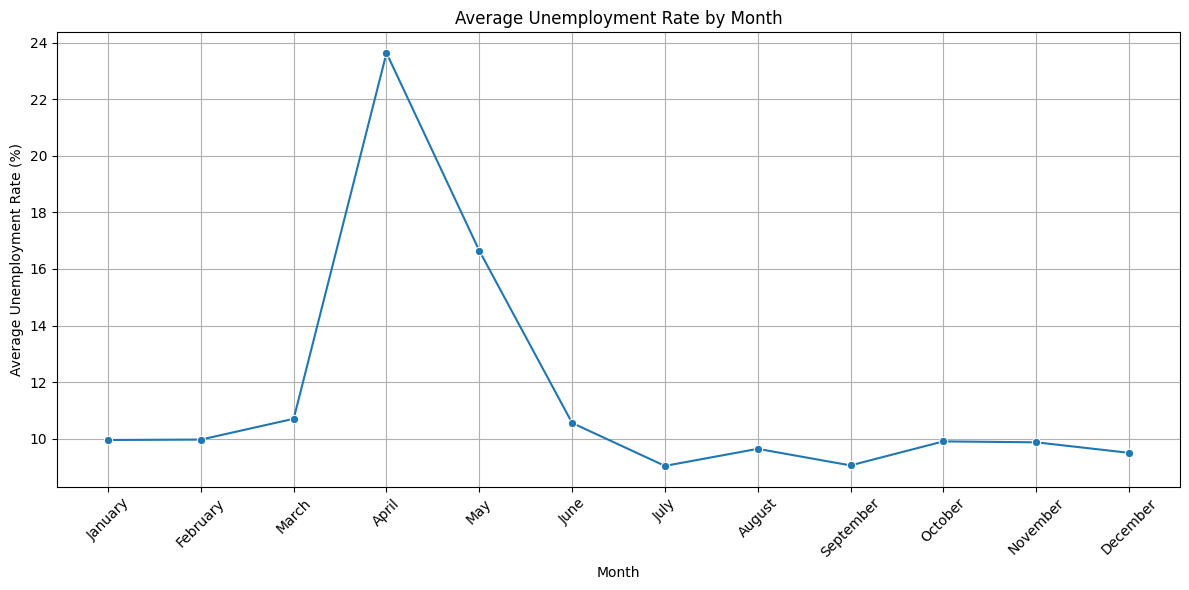

In [22]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_pattern = (
    df1.groupby('Month')['Estimated Unemployment Rate (%)']
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values,
    marker='o'
)

plt.title('Average Unemployment Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

The monthly average unemployment trend indicates that unemployment levels vary throughout the year rather than remaining constant. Some months record higher unemployment rates while others show improved employment conditions. These fluctuations may be influenced by seasonal factors such as agricultural cycles, festival-related economic activity, temporary hiring patterns, and changing labour demand across industries.

## Correlation Heatmap

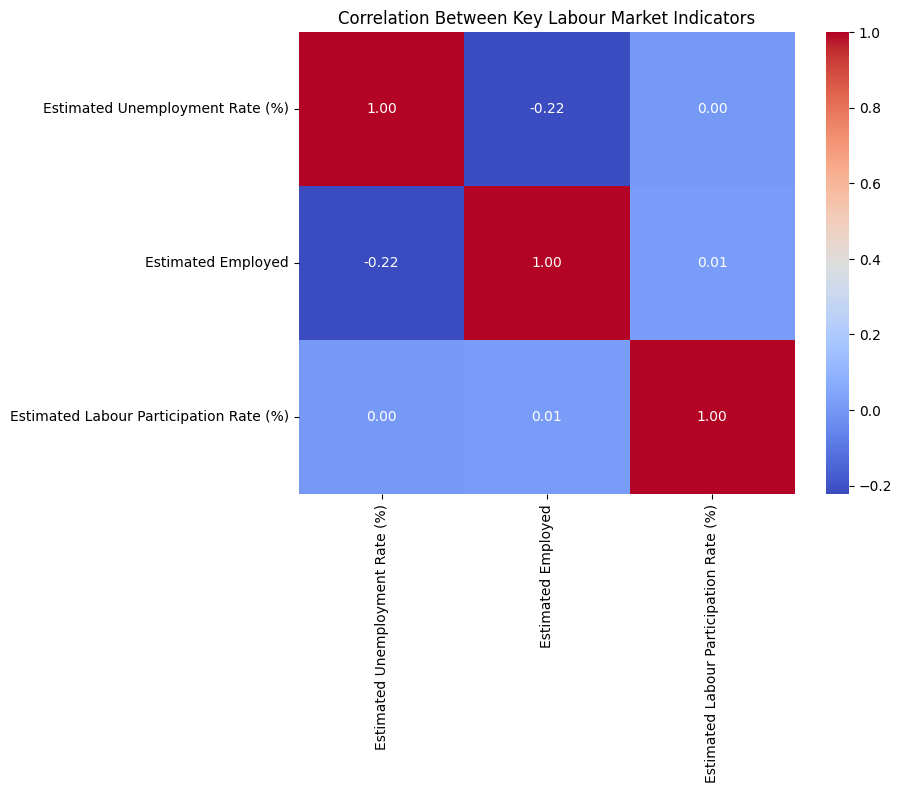

In [23]:
corr = df1[
[
'Estimated Unemployment Rate (%)',
'Estimated Employed',
'Estimated Labour Participation Rate (%)'
]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Key Labour Market Indicators')

plt.show()

The heatmap shows the strength and direction of relationships among unemployment rate, employment levels, and labour force participation. Positive correlations indicate that two variables tend to move in the same direction, while negative correlations indicate opposite movement. Understanding these relationships helps provide a more comprehensive view of labour market dynamics beyond unemployment alone.

## Key Findings
* Unemployment remained relatively stable before COVID-19.
* April–May 2020 recorded the sharpest increase in unemployment.
* Significant regional disparities exist across states.
* Urban areas experienced stronger unemployment shocks than rural areas.
* Labour market indicators show meaningful interrelationships.

## Final Conclusion

The analysis reveals significant variation in unemployment across time, regions, and area types in India. While unemployment remained relatively stable during most of 2019, the COVID-19 pandemic caused a sharp increase in joblessness across the country. Regional disparities indicate that some states consistently face greater employment challenges than others, while urban areas experienced stronger shocks compared to rural areas. Seasonal patterns and correlations among labour market indicators further demonstrate that unemployment is influenced by multiple economic factors. These findings highlight the importance of region-specific and data-driven policies to improve employment opportunities and strengthen labour market resilience during future economic disruptions.